# **Ingenieria de caracteristicas:**

In [ ]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

# Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta al CSV en Drive
df = pd.read_csv("/content/drive/MyDrive/Proyecto_Tecnicas_ML/df_cleaned_02.csv")
display(df.head(5))

,PERIODO,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,...,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,2018,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGO...,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,No,No,Entre 11 y 20 horas,N,...,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,161.0,174.0,139.0,161.0,128.0
1,2018,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Más de 30 horas,N,...,Si,Estrato 2,Si,Si,No sabe,142.0,77.0,124.0,130.0,153.0
2,2018,PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.,UNIVERSIDAD,ADMINISTRACIÓN,PRESENCIAL,Más de 7 millones,No,Si,0,N,...,Si,Estrato 4,Si,Si,Técnica o tecnológica incompleta,128.0,165.0,169.0,159.0,124.0
3,2018,UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNA...,UNIVERSIDAD,PSICOLOGÍA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Menos de 10 horas,N,...,Si,Estrato 3,Si,Si,Técnica o tecnológica completa,108.0,157.0,148.0,115.0,142.0
4,2018,POLITECNICO GRANCOLOMBIANO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,DISTANCIA VITUAL,Entre 1 millón y menos de 2.5 millones,No,No,NaN,N,...,NaN,NaN,NaN,NaN,NaN,132.0,116.0,101.0,123.0,107.0


In [ ]:
# Get the number of rows and columns
num_rows, num_cols = df.shape

# Display the number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 451782
Number of columns: 25


##Se crea la varible puntaje global (0-300):

se calcula sumando los puntajes indivuales y dividiendo en 5, como indica la cartilla de informacion del icfes saber pro: https://www.icfes.gov.co/wp-content/uploads/2025/03/00_entender_resultados_Saber_PRO.pdf


In [ ]:
# Define the score columns
score_columns_individual = [
    'MOD_LECTURA_CRITICA_PUNT',
    'MOD_RAZONA_CUANTITAT_PUNT',
    'MOD_COMPETEN_CIUDADA_PUNT',
    'MOD_COMUNI_ESCRITA_PUNT',
    'MOD_INGLES_PUNT'
]

# Calculate the sum of individual scores
df['sum_individual_scores'] = df[score_columns_individual].sum(axis=1)

# Calculate the average score (puntaje global 3)
df['puntaje global'] = df['sum_individual_scores'] / 5

# Drop the intermediate sum column
df = df.drop(columns=['sum_individual_scores','MOD_RAZONA_CUANTITAT_PUNT','MOD_COMUNI_ESCRITA_PUNT', 'MOD_LECTURA_CRITICA_PUNT','MOD_INGLES_PUNT','MOD_COMPETEN_CIUDADA_PUNT'])

# Display the first few rows with the new 'puntaje global 3' column
display(df.head())

,PERIODO,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,...,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global
0,2018,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGO...,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,No,No,Entre 11 y 20 horas,N,...,Si,No,Primaria completa,Si,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,152.6
1,2018,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Más de 30 horas,N,...,No,Si,No Aplica,No,Si,Estrato 2,Si,Si,No sabe,125.2
2,2018,PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.,UNIVERSIDAD,ADMINISTRACIÓN,PRESENCIAL,Más de 7 millones,No,Si,0,N,...,Si,Si,Educación profesional incompleta,Si,Si,Estrato 4,Si,Si,Técnica o tecnológica incompleta,149.0
3,2018,UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNA...,UNIVERSIDAD,PSICOLOGÍA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Menos de 10 horas,N,...,No,Si,Técnica o tecnológica completa,Si,Si,Estrato 3,Si,Si,Técnica o tecnológica completa,134.0
4,2018,POLITECNICO GRANCOLOMBIANO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,DISTANCIA VITUAL,Entre 1 millón y menos de 2.5 millones,No,No,NaN,N,...,No,Si,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.8


In [ ]:
# Calculate the maximum and minimum values of 'puntaje global2'
max_puntaje_global2 = df['puntaje global'].max()
min_puntaje_global2 = df['puntaje global'].min()

# Display the maximum and minimum values
print(f"Maximum 'puntaje global': {max_puntaje_global2}")
print(f"Minimum 'puntaje global': {min_puntaje_global2}")

Maximum 'puntaje global': 278.2
Minimum 'puntaje global': 0.0


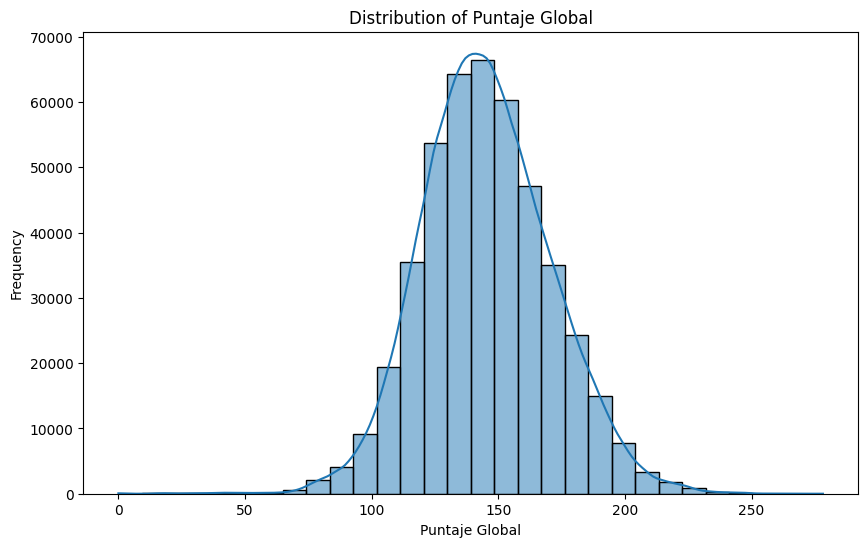

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['puntaje global'], kde=True, bins=30)
plt.title('Distribution of Puntaje Global')
plt.xlabel('Puntaje Global')
plt.ylabel('Frequency')
plt.show()

se toma el valor mas grande del intervalo y se pasa a numero, es mejor sobreestimar el valor de la matricula, ya que incrementa anualmente, tambien se tranforma el numero de horas trabajadas Nan a 0, el valor maximo del los intervalos (porque no trabaja de esas horas) o el minimo en el caso donde solo habia esa informacion (ej:Más de 30 horas) porque es un numero de hora que si o si trabaja.

Se tranforma EN ESTU_METODO_PRGM en dos categorias presencial y a distancia, (se borra distancia vitual, y virtual porque son lo mismo)
SE borran el nombre de la universidad, el perioodo y el caracter academico.

se trasforma la varible FAMI_ESTRATOVIVIENDA a numerico y los  sin estrato se tranforman a cero que son consideradas personas sin hogar.

In [ ]:
#TRANSFORMACIÓN ESTU_HORASSEMANATRABAJA
def extract_numeric_hours(value):
    """
    Extracts a numerical representation from the ESTU_HORASSEMANATRABAJA string.
    Returns the upper bound of the range, the specified value for 'Más de' and 'Menos de',
    and 0 for NaN values.
    """
    if pd.isna(value):
        return 0
    value = value.lower()
    if 'menos de' in value:
        return 10.0
    elif 'más de' in value:
        return 30.0
    elif 'y' in value and 'horas' in value:
        try:
            parts = value.split('y')
            if len(parts) > 1:
                return float(parts[1].split()[0])
            else:
                return np.nan # Should not happen based on the categories, but as a fallback
        except (ValueError, IndexError):
            return np.nan # Handle potential errors during conversion
    elif value.isdigit(): # Handle cases that are already just numbers
        return float(value)
    else:
        return np.nan # Handle any other unexpected formats

# Apply the function to the column
df['ESTU_HORASSEMANATRABAJA'] = df['ESTU_HORASSEMANATRABAJA'].apply(extract_numeric_hours)

#TRANSFORMACIÓN ESTU_VALORMATRICULAUNIVERSIDAD
def extract_numeric_matricula(value):
    """
    Extracts a numerical representation from the ESTU_VALORMATRICULAUNIVERSIDAD string.
    Returns the upper bound of the range or the lower bound for "Más de".
    """
    if pd.isna(value):
        return np.nan
    value = value.lower()
    if 'menos de' in value:
        # Extract the upper bound
        return float(value.split('menos de')[1].split()[0])
    elif 'más de' in value:
        # Extract the lower bound
        return float(value.split('más de')[1].split()[0])
    elif 'y' in value and 'millones' in value:
        # Handle ranges like "Entre X y Y millones", take the upper bound
        parts = value.split('y')
        if len(parts) > 1:
            try:
                return float(parts[1].split()[0])
            except (ValueError, IndexError):
                return np.nan
        else:
            return np.nan
    else:
        # Handle any other cases, return NaN or a default value if needed
        return np.nan

# Apply the function to the column
df['ESTU_VALORMATRICULAUNIVERSIDAD'] = df['ESTU_VALORMATRICULAUNIVERSIDAD'].apply(extract_numeric_matricula)

#TRANSFORMACIÓN FAMI_ESTRATOVIVIENDA
def transform_estrato_to_numeric(value):
    """
    Transforms the 'FAMI_ESTRATOVIVIENDA' values to a numerical representation.
    'Estrato X' becomes X, and 'Sin Estrato' becomes 0. NaN values are kept as NaN.
    """
    if pd.isna(value):
        return np.nan # Keep NaN as NaN
    elif value == 'Sin Estrato':
        return 0
    elif 'Estrato' in value:
        try:
            # Extract the number after 'Estrato '
            return int(value.split(' ')[1])
        except (ValueError, IndexError):
            # Handle cases where the format might be unexpected
            return np.nan # Or return 0, depending on how you want to handle errors
    else:
        # Handle any other unexpected values
        return np.nan # Or return 0

# Apply the function to the 'FAMI_ESTRATOVIVIENDA' column
df['FAMI_ESTRATOVIVIENDA'] = df['FAMI_ESTRATOVIVIENDA'].apply(transform_estrato_to_numeric)


# CONSOLIDAR CATEGORÍAS EN ESTU_METODO_PRGM
df['ESTU_METODO_PRGM'] = df['ESTU_METODO_PRGM'].replace(['DISTANCIA VITUAL', 'VIRTUAL'], 'DISTANCIA')


# ELIMINACIÓN DE VARIABLES
df = df.drop(columns=['INST_NOMBRE_INSTITUCION', 'INST_CARACTER_ACADEMICO','PERIODO','ESTU_VALORMATRICULAUNIVERSIDAD' ])

# Display the first few rows to verify the columns have been removed
display(df.head())

,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global
0,ADMINISTRACIÓN,PRESENCIAL,No,No,20.0,N,F,Si,No,Primaria completa,Si,Si,2.0,Si,Si,Secundaria (Bachillerato) incompleta,152.6
1,CONTADURÍA PUBLICA,DISTANCIA,No,No,30.0,N,M,No,Si,No Aplica,No,Si,2.0,Si,Si,No sabe,125.2
2,ADMINISTRACIÓN,PRESENCIAL,No,Si,0.0,N,F,Si,Si,Educación profesional incompleta,Si,Si,4.0,Si,Si,Técnica o tecnológica incompleta,149.0
3,PSICOLOGÍA,DISTANCIA,No,No,10.0,N,M,No,Si,Técnica o tecnológica completa,Si,Si,3.0,Si,Si,Técnica o tecnológica completa,134.0
4,ADMINISTRACIÓN,DISTANCIA,No,No,0.0,N,M,No,Si,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.8



se fusionan las columnas ESTU_PAGOMATRICULABECA, ESTU_PAGOMATRICULACREDITO , ESTU_PAGOMATRICULAPADRES, ESTU_PAGOMATRICULAPROPIO en una sola variable categorica que sea PAGO_MATRICULA: donde ESTU_PAGOMATRICULABECA es si enconces pone BECA, o ESTU_PAGOMATRICULACREDITO es entonces pone CREDITO, ESTU_PAGOMATRICULAPADRES es si pone PADRES, o ESTU_PAGOMATRICULAPROPIO es si pone PROPIO

Si ninguna de las columnas de pago originales es 'Si', asignaremos una categoría por defecto, por ejemplo, 'NINGUNO'.

In [ ]:
def create_pago_matricula_category(row):
    """
    Creates the 'PAGO_MATRICULA' category based on the values in the payment columns.
    Prioritizes BECA, then CREDITO, then PADRES, then PROPIO.
    """
    if row['ESTU_PAGOMATRICULABECA'] == 'Si':
        return 'BECA'
    elif row['ESTU_PAGOMATRICULACREDITO'] == 'Si':
        return 'CREDITO'
    elif row['ESTU_PAGOMATRICULAPADRES'] == 'Si':
        return 'PADRES'
    elif row['ESTU_PAGOMATRICULAPROPIO'] == 'Si':
        return 'PROPIO'
    else:
        return 'NINGUNO' # Or another appropriate default category

# Apply the function to create the new 'PAGO_MATRICULA' column
df['PAGO_MATRICULA'] = df.apply(create_pago_matricula_category, axis=1)

# Drop the original payment columns
df = df.drop(columns=['ESTU_PAGOMATRICULABECA', 'ESTU_PAGOMATRICULACREDITO', 'ESTU_PAGOMATRICULAPADRES', 'ESTU_PAGOMATRICULAPROPIO'])

# Display the first few rows with the new column and without the old ones
display(df.head())

# Display the unique values in the new column
print("\nUnique values in 'PAGO_MATRICULA':")
print(df['PAGO_MATRICULA'].unique())

,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global,PAGO_MATRICULA
0,ADMINISTRACIÓN,PRESENCIAL,20.0,N,F,Primaria completa,Si,Si,2.0,Si,Si,Secundaria (Bachillerato) incompleta,152.6,PADRES
1,CONTADURÍA PUBLICA,DISTANCIA,30.0,N,M,No Aplica,No,Si,2.0,Si,Si,No sabe,125.2,PROPIO
2,ADMINISTRACIÓN,PRESENCIAL,0.0,N,F,Educación profesional incompleta,Si,Si,4.0,Si,Si,Técnica o tecnológica incompleta,149.0,CREDITO
3,PSICOLOGÍA,DISTANCIA,10.0,N,M,Técnica o tecnológica completa,Si,Si,3.0,Si,Si,Técnica o tecnológica completa,134.0,PROPIO
4,ADMINISTRACIÓN,DISTANCIA,0.0,N,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.8,PROPIO



Unique values in 'PAGO_MATRICULA':
['PADRES' 'PROPIO' 'CREDITO' 'BECA' 'NINGUNO']


SE TRANFORMA  FAMI_EDUCACIONMADRE A siete valores: ninguno, primaria, bachillerato, tecnico, profesional, postgrado, no sabe.  aquellos que originalmente aparecen incompleto (ej: secundaria incompleta ) se reemplazan por el ultimo nivel de educacion completado (obtuvieron el titulo)  excepto primaria.  lo mismo con padre


(tranforma los valores de FAMI_EDUCACIONMADRE por: Secundaria (Bachillerato) incompleta a Primaria, Técnica o tecnológica incompleta a Bachillerato, Técnica o tecnológica completa a Técnica, Primaria completa a Primaria, Primaria incompleta a Primaria, Postgrado a Postgrado, Secundaria (Bachillerato) completa a Bachillerato, Educación profesional incompleta a Bachillerato, Educación profesional completa a profesional, No Aplica a Ninguno, Ninguno a Ninguno.)


(tranforma los valores de FAMI_EDUCACIONPADRE por: Primaria completa por Primaria, No Aplica a Ninguno, Educación profesional incompleta a Bachillerato, Técnica o tecnológica completa a Técnica,Postgrado a Postgrado, Secundaria (Bachillerato) incompleta a Primaria, Primaria incompleta a Primaria, Técnica o tecnológica incompleta a Bachillerato, Ninguno a Ninguno, Educación profesional completa a profesional, Secundaria (Bachillerato) completa a Bachillerato, nan a No sabe)

In [ ]:
# Display unique values for FAMI_EDUCACIONMADRE
print("Unique values in 'FAMI_EDUCACIONMADRE':")
print(df['FAMI_EDUCACIONMADRE'].unique())

# Display unique values for FAMI_EDUCACIONPADRE
print("\nUnique values in 'FAMI_EDUCACIONPADRE':")
print(df['FAMI_EDUCACIONPADRE'].unique())

Unique values in 'FAMI_EDUCACIONMADRE':
['Secundaria (Bachillerato) incompleta' 'No sabe'
 'Técnica o tecnológica incompleta' 'Técnica o tecnológica completa' nan
 'Primaria completa' 'Primaria incompleta' 'Postgrado'
 'Secundaria (Bachillerato) completa' 'Ninguno'
 'Educación profesional incompleta' 'Educación profesional completa'
 'No Aplica']

Unique values in 'FAMI_EDUCACIONPADRE':
['Primaria completa' 'No Aplica' 'Educación profesional incompleta'
 'Técnica o tecnológica completa' nan 'Postgrado'
 'Secundaria (Bachillerato) incompleta' 'Primaria incompleta'
 'Técnica o tecnológica incompleta' 'Ninguno'
 'Educación profesional completa' 'Secundaria (Bachillerato) completa'
 'No sabe']


In [ ]:
# Define the mapping for FAMI_EDUCACIONMADRE
education_mapping_madre = {
    'Secundaria (Bachillerato) incompleta': 'Primaria',
    'Técnica o tecnológica incompleta': 'Bachillerato',
    'Técnica o tecnológica completa': 'Técnica',
    'Primaria completa': 'Primaria',
    'Primaria incompleta': 'Primaria',
    'Postgrado': 'Postgrado',
    'Secundaria (Bachillerato) completa': 'Bachillerato',
    'Educación profesional incompleta': 'Bachillerato',
    'Educación profesional completa': 'Profesional',
    'No Aplica': 'Ninguno',
    'Ninguno': 'Ninguno',
    np.nan: 'No sabe' # Add mapping for NaN values
}

# Apply the mapping to the 'FAMI_EDUCACIONMADRE' column
df['FAMI_EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].replace(education_mapping_madre)

# Define the mapping for FAMI_EDUCACIONPADRE
education_mapping_padre = {
    'Primaria completa': 'Primaria',
    'No Aplica': 'Ninguno',
    'Educación profesional incompleta': 'Bachillerato',
    'Técnica o tecnológica completa': 'Técnica',
    'Postgrado': 'Postgrado',
    'Secundaria (Bachillerato) incompleta': 'Primaria',
    'Primaria incompleta': 'Primaria',
    'Técnica o tecnológica incompleta': 'Bachillerato',
    'Ninguno': 'Ninguno',
    'Educación profesional completa': 'Profesional',
    'Secundaria (Bachillerato) completa': 'Bachillerato',
    np.nan: 'No sabe' # Add mapping for NaN values
}

# Apply the mapping to the 'FAMI_EDUCACIONPADRE' column
df['FAMI_EDUCACIONPADRE'] = df['FAMI_EDUCACIONPADRE'].replace(education_mapping_padre)


# Display the first few rows with the new column and without the old ones
display(df.head())

,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global,PAGO_MATRICULA
0,ADMINISTRACIÓN,PRESENCIAL,20.0,N,F,Primaria,Si,Si,2.0,Si,Si,Primaria,152.6,PADRES
1,CONTADURÍA PUBLICA,DISTANCIA,30.0,N,M,Ninguno,No,Si,2.0,Si,Si,No sabe,125.2,PROPIO
2,ADMINISTRACIÓN,PRESENCIAL,0.0,N,F,Bachillerato,Si,Si,4.0,Si,Si,Bachillerato,149.0,CREDITO
3,PSICOLOGÍA,DISTANCIA,10.0,N,M,Técnica,Si,Si,3.0,Si,Si,Técnica,134.0,PROPIO
4,ADMINISTRACIÓN,DISTANCIA,0.0,N,M,No sabe,NaN,NaN,NaN,NaN,NaN,No sabe,115.8,PROPIO


In [ ]:
# Get the number of unique values for each column
unique_values_count = df.nunique()

# Display the count of unique values per column
print("Number of unique values per column:")
print(unique_values_count)

Number of unique values per column:
ESTU_NUCLEO_PREGRADO         35
ESTU_METODO_PRGM              2
ESTU_HORASSEMANATRABAJA       4
ESTU_PRIVADO_LIBERTAD         2
ESTU_GENERO                   2
FAMI_EDUCACIONPADRE           7
FAMI_TIENEAUTOMOVIL           2
FAMI_TIENELAVADORA            2
FAMI_ESTRATOVIVIENDA          7
FAMI_TIENECOMPUTADOR          2
FAMI_TIENEINTERNET            2
FAMI_EDUCACIONMADRE           7
puntaje global             1185
PAGO_MATRICULA                5
dtype: int64


###Nulos:
se eliminan las filas con valores nulos ya que no representan un porcentaje significativo responto al volumen totoal de datos (451782)

In [ ]:
# Calculate the number of null values per column
null_counts = df.isnull().sum()

# Display the null counts
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
ESTU_NUCLEO_PREGRADO           0
ESTU_METODO_PRGM               0
ESTU_HORASSEMANATRABAJA        0
ESTU_PRIVADO_LIBERTAD          0
ESTU_GENERO                   48
FAMI_EDUCACIONPADRE            0
FAMI_TIENEAUTOMOVIL        26829
FAMI_TIENELAVADORA         23912
FAMI_ESTRATOVIVIENDA       19308
FAMI_TIENECOMPUTADOR       22720
FAMI_TIENEINTERNET         16751
FAMI_EDUCACIONMADRE            0
puntaje global                 0
PAGO_MATRICULA                 0
dtype: int64


In [ ]:
# Drop rows with any null values
df = df.dropna()

# Display the number of rows after dropping nulls
print(f"Number of rows after dropping nulls: {len(df)}")

# Display the first few rows of the dataframe after dropping nulls
display(df.head())

Number of rows after dropping nulls: 419809


,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,ESTU_GENERO,FAMI_EDUCACIONPADRE,FAMI_TIENEAUTOMOVIL,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,puntaje global,PAGO_MATRICULA
0,ADMINISTRACIÓN,PRESENCIAL,20.0,N,F,Primaria,Si,Si,2.0,Si,Si,Primaria,152.6,PADRES
1,CONTADURÍA PUBLICA,DISTANCIA,30.0,N,M,Ninguno,No,Si,2.0,Si,Si,No sabe,125.2,PROPIO
2,ADMINISTRACIÓN,PRESENCIAL,0.0,N,F,Bachillerato,Si,Si,4.0,Si,Si,Bachillerato,149.0,CREDITO
3,PSICOLOGÍA,DISTANCIA,10.0,N,M,Técnica,Si,Si,3.0,Si,Si,Técnica,134.0,PROPIO
5,ADMINISTRACIÓN,PRESENCIAL,30.0,N,F,Primaria,Si,Si,3.0,Si,Si,Primaria,128.4,BECA


In [ ]:
# Calculate the number of null values per column
null_counts = df.isnull().sum()

# Display the null counts
print("Number of null values per column:")
print(null_counts)

Number of null values per column:
ESTU_NUCLEO_PREGRADO       0
ESTU_METODO_PRGM           0
ESTU_HORASSEMANATRABAJA    0
ESTU_PRIVADO_LIBERTAD      0
ESTU_GENERO                0
FAMI_EDUCACIONPADRE        0
FAMI_TIENEAUTOMOVIL        0
FAMI_TIENELAVADORA         0
FAMI_ESTRATOVIVIENDA       0
FAMI_TIENECOMPUTADOR       0
FAMI_TIENEINTERNET         0
FAMI_EDUCACIONMADRE        0
puntaje global             0
PAGO_MATRICULA             0
dtype: int64


In [ ]:
# renombra una sola vez y el resto del código puede seguir usando PUNTAJE_GLOBAL
if "puntaje global" in df.columns:
    df.rename(columns={"puntaje global": "PUNTAJE_GLOBAL"}, inplace=True)


In [ ]:
# Get the number of rows and columns
num_rows, num_cols = df.shape

# Display the number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 419809
Number of columns: 14


In [ ]:
print(df.columns)

Index(['ESTU_NUCLEO_PREGRADO', 'ESTU_METODO_PRGM', 'ESTU_HORASSEMANATRABAJA',
       'ESTU_PRIVADO_LIBERTAD', 'ESTU_GENERO', 'FAMI_EDUCACIONPADRE',
       'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENELAVADORA', 'FAMI_ESTRATOVIVIENDA',
       'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'FAMI_EDUCACIONMADRE',
       'PUNTAJE_GLOBAL', 'PAGO_MATRICULA'],
      dtype='object')


#**Cluster**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Numéricas candidatas
num_candidates = [
    "PUNTAJE_GLOBAL",
    "FAMI_ESTRATOVIVIENDA",
    "ESTU_HORASSEMANATRABAJA",
]

# Categóricas candidatas
cat_candidates = [
    "ESTU_METODO_PRGM",
    "PAGO_MATRICULA",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "GENDER", "MINORITY", "JOBCAT",
]

num_cols = [c for c in num_candidates if c in df.columns]
cat_cols = [c for c in cat_candidates if c in df.columns]

if not num_cols and not cat_cols:
    raise ValueError("No se encontraron columnas válidas para segmentar.")

In [ ]:
# Preprocesamiento
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

In [ ]:
# Matriz de features
X = df[num_cols + cat_cols].copy()
X_proc = preprocess.fit_transform(X)
# Recuperar nombres de columnas transformadas
feat_names = []
if num_cols:
    feat_names += num_cols
if cat_cols:
    ohe = preprocess.named_transformers_["cat"].named_steps["ohe"]
    cat_ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feat_names += cat_ohe_names

In [ ]:
#Separacion del data set
rng = np.random.RandomState(17)
n = X_proc.shape[0]
sample_size = min(50000, n)
idx = rng.choice(n, size=sample_size, replace=False)

X_sample = X_proc[idx]


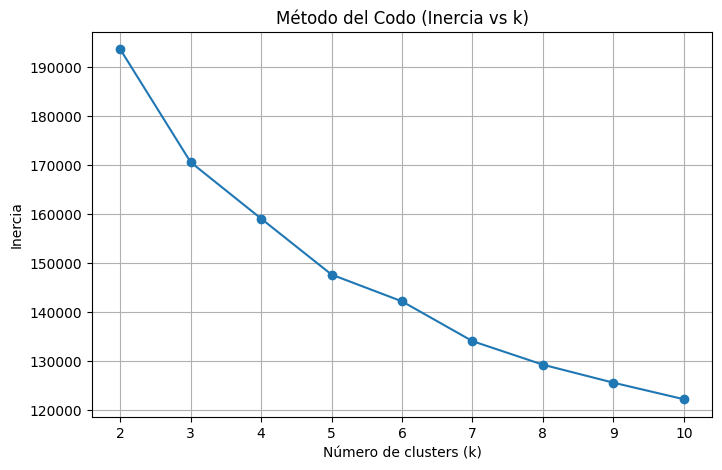

In [ ]:
# Método del Codo

inertias = []
candidate_ks = range(2, 11)

for k in candidate_ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=17, batch_size=2048, n_init="auto")
    km.fit(X_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(candidate_ks, inertias, marker='o')
plt.title("Método del Codo (Inercia vs k)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


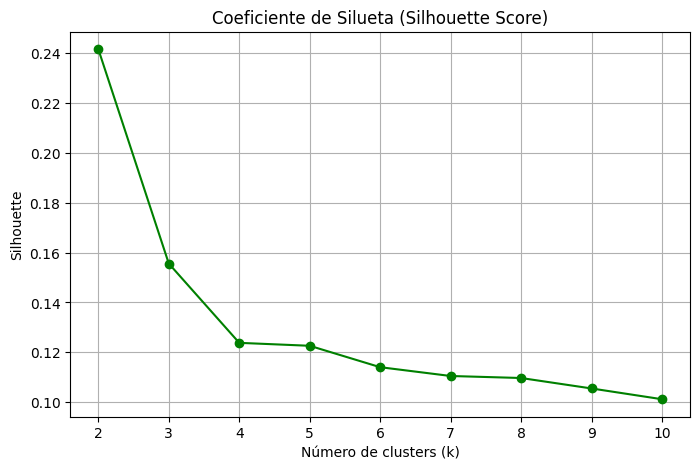

In [ ]:
# Gráfico de Silhouette Score
from sklearn.metrics import silhouette_score

silhouettes = []
candidate_ks = range(2, 11)

for k in candidate_ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=17, batch_size=2048, n_init="auto")
    labels = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels, metric="euclidean")
    silhouettes.append(sil)

plt.figure(figsize=(8,5))
plt.plot(candidate_ks, silhouettes, marker='o', color='green')
plt.title("Coeficiente de Silueta (Silhouette Score)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()


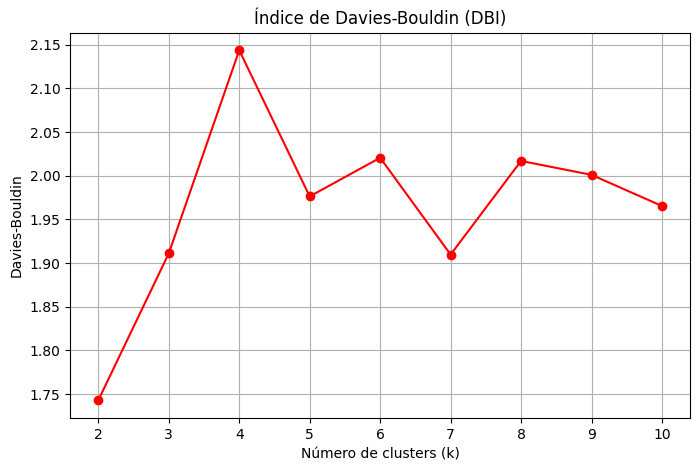

In [ ]:
# Índice de Davies-Bouldin
from sklearn.metrics import davies_bouldin_score

dbi_scores = []
candidate_ks = range(2, 11)

for k in candidate_ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=17, batch_size=2048, n_init="auto")
    labels = km.fit_predict(X_sample)
    dbi = davies_bouldin_score(X_sample, labels)
    dbi_scores.append(dbi)

plt.figure(figsize=(8,5))
plt.plot(candidate_ks, dbi_scores, marker='o', color='red')
plt.title("Índice de Davies-Bouldin (DBI)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin")
plt.grid(True)
plt.show()


De los graficos podemos tener en concideracion que el k mas optimo es 2, teniendo en cuenta que de esta manera seria un caso en el cual cada diferencia puede ser visualizada e interfiere. Por motivos del analisis utilizaremos tando el k = 2 como el k=3 que entre todos los demas tambien tiene buenos rendimientos

In [ ]:
# Ajustar K-Means sobre el dataset y asignar clúster
# KMeans con k=2
kmeans2 = MiniBatchKMeans(n_clusters=2, random_state=17, batch_size=2048, n_init="auto")
clusters2 = kmeans2.fit_predict(X_proc)
df["cluster_k2"] = clusters2   # columna distinta

#  KMeans con k=3
kmeans3 = MiniBatchKMeans(n_clusters=3, random_state=17, batch_size=2048, n_init="auto")
clusters3 = kmeans3.fit_predict(X_proc)
df["cluster_k3"] = clusters3

In [ ]:
def perfilar_clusters(df, cluster_col, num_cols, cat_cols):
    perfil_numericas = pd.DataFrame()
    if num_cols:
        perfil_numericas = (
            df.groupby(cluster_col)[num_cols]
              .agg(["mean", "median", "std", "count"])
              .round(3)
        )

    def dist_categorica_por_cluster(df, col, cluster_col):
        tabla = (
            df.groupby(cluster_col)[col]
              .value_counts(normalize=True)
              .mul(100)
              .rename("pct")
              .reset_index()
              .pivot(index=cluster_col, columns=col, values="pct")
              .fillna(0.0)
              .round(2)
        )
        return tabla

    perfil_categoricas = {}
    for c in cat_cols:
        perfil_categoricas[c] = dist_categorica_por_cluster(df, c, cluster_col)

    print(f"\n=== Perfil numérico para {cluster_col} ===")
    if not perfil_numericas.empty:
        print(perfil_numericas)

    print(f"\n=== Perfil categórico para {cluster_col} ===")
    for c, tabla in perfil_categoricas.items():
        print(f"\n{c}:")
        print(tabla)

    return perfil_numericas, perfil_categoricas


perfil_num_k2, perfil_cat_k2 = perfilar_clusters(df, "cluster_k2", num_cols, cat_cols)
perfil_num_k3, perfil_cat_k3 = perfilar_clusters(df, "cluster_k3", num_cols, cat_cols)



=== Perfil numérico para cluster_k2 ===
           PUNTAJE_GLOBAL                        FAMI_ESTRATOVIVIENDA         \
                     mean median     std   count                 mean median   
cluster_k2                                                                     
0                 133.844  134.4  18.768  261297                2.136    2.0   
1                 165.990  165.6  21.424  158512                3.306    3.0   

                          ESTU_HORASSEMANATRABAJA                         
              std   count                    mean median     std   count  
cluster_k2                                                                
0           0.752  261297                  25.843   30.0   7.832  261297  
1           1.031  158512                  15.941   20.0  12.647  158512  

=== Perfil categórico para cluster_k2 ===

ESTU_METODO_PRGM:
ESTU_METODO_PRGM  DISTANCIA  PRESENCIAL
cluster_k2                             
0                     55.59       44.41
1

In [ ]:
pca = PCA(n_components=2, random_state=17)
X_pca = pca.fit_transform(X_proc)

In [ ]:
y2 = df["cluster_k2"].values
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_proc, y2, test_size=0.2, random_state=17, stratify=y2)

clf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=17
)
clf2.fit(X_train2, y_train2)
y_pred2 = clf2.predict(X_test2)

print("\n=== Clasificación de clústeres k=2 (RandomForest) ===")
print(classification_report(y_test2, y_pred2, digits=3))

importances2 = pd.Series(clf2.feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nTop features más importantes para clasificar clústeres k=2:")
print(importances2.head(20))


=== Clasificación de clústeres k=2 (RandomForest) ===
              precision    recall  f1-score   support

           0      0.997     0.998     0.997     52260
           1      0.997     0.994     0.996     31702

    accuracy                          0.997     83962
   macro avg      0.997     0.996     0.996     83962
weighted avg      0.997     0.997     0.997     83962


Top features más importantes para clasificar clústeres k=2:
PUNTAJE_GLOBAL                     0.375403
FAMI_ESTRATOVIVIENDA               0.222791
ESTU_HORASSEMANATRABAJA            0.144532
ESTU_METODO_PRGM_PRESENCIAL        0.083507
FAMI_EDUCACIONMADRE_Primaria       0.050553
FAMI_EDUCACIONPADRE_Primaria       0.041507
PAGO_MATRICULA_PADRES              0.028645
PAGO_MATRICULA_PROPIO              0.013159
FAMI_EDUCACIONMADRE_Profesional    0.011415
FAMI_EDUCACIONPADRE_Profesional    0.007998
FAMI_EDUCACIONPADRE_Postgrado      0.006358
FAMI_EDUCACIONMADRE_Postgrado      0.005635
PAGO_MATRICULA_CREDITO       

In [ ]:
y3 = df["cluster_k3"].values
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_proc, y3, test_size=0.2, random_state=17, stratify=y3)

clf3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=17
)
clf3.fit(X_train3, y_train3)
y_pred3 = clf3.predict(X_test3)

print("\n=== Clasificación de clústeres k=3 (RandomForest) ===")
print(classification_report(y_test3, y_pred3, digits=3))

importances3 = pd.Series(clf3.feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nTop features más importantes para clasificar clústeres k=3:")
print(importances3.head(20))


=== Clasificación de clústeres k=3 (RandomForest) ===
              precision    recall  f1-score   support

           0      0.996     0.996     0.996     34765
           1      0.996     0.997     0.997     32785
           2      0.996     0.995     0.996     16412

    accuracy                          0.996     83962
   macro avg      0.996     0.996     0.996     83962
weighted avg      0.996     0.996     0.996     83962


Top features más importantes para clasificar clústeres k=3:
ESTU_HORASSEMANATRABAJA            0.332879
PUNTAJE_GLOBAL                     0.320366
FAMI_ESTRATOVIVIENDA               0.195196
ESTU_METODO_PRGM_PRESENCIAL        0.058885
FAMI_EDUCACIONMADRE_Primaria       0.030696
FAMI_EDUCACIONPADRE_Primaria       0.024358
PAGO_MATRICULA_PADRES              0.010155
PAGO_MATRICULA_PROPIO              0.007297
FAMI_EDUCACIONMADRE_Profesional    0.003959
FAMI_EDUCACIONPADRE_Profesional    0.003399
FAMI_EDUCACIONPADRE_Postgrado      0.002935
FAMI_EDUCACIONMADRE

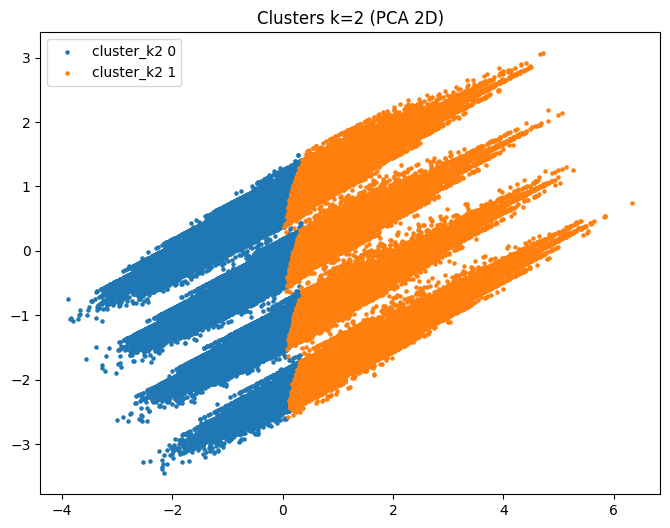

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for lab in np.unique(df["cluster_k2"]):
    m = df["cluster_k2"] == lab
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=5, label=f"cluster_k2 {lab}")
plt.title("Clusters k=2 (PCA 2D)")
plt.legend()
plt.show()

*  Cluster 0 — “Bajo puntaje, estrato bajo, modalidad a distancia, trabaja bastante”

    - Rendimiento: puntaje global más bajo (media 133.8, mediana 134.4).
    - Estrato: más bajo (media 2.13, mediana 2).
    - Trabajo: muchas horas (media 25.8, mediana 30).
    - Programa: predominan DISTANCIA (55.6%).
    - Pago matrícula: más PROPIO (35.1%) y CRÉDITO (33.1%), menos apoyo de PADRES (15.7%).
    - Educación de padres: predominio de Primaria (madre 54.4%, padre 55.6%), muy bajo nivel Profesional/Postgrado (<6%).

---

*  Cluster 1 — “Alto puntaje, estrato medio-alto, presencial, trabaja menos, padres pagan”

    - Rendimiento: puntaje global más alto (media 166.0, mediana 165.6).
    - Estrato: más alto (media 3.31, mediana 3).
    - Trabajo: menos horas (media 15.9, mediana 20).
    - Programa: fuertemente PRESENCIAL (89.3%).
    - Pago matrícula: principalmente PADRES (46.9%), menor peso de CRÉDITO (26.2%) y muy poco PROPIO (10.9%).
    - Educación de padres: mayor nivel académico, con Profesional (madre 22.7%, padre 21.4%) y Postgrado (~15% en ambos).

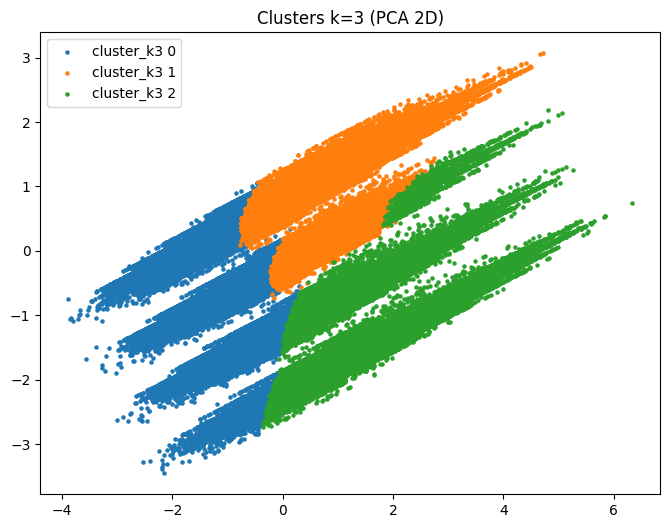

In [ ]:
plt.figure(figsize=(8,6))
for lab in np.unique(df["cluster_k3"]):
    m = df["cluster_k3"] == lab
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=5, label=f"cluster_k3 {lab}")
plt.title("Clusters k=3 (PCA 2D)")
plt.legend()
plt.show()

*  Cluster 0 — “Bajo puntaje, estrato bajo, modalidad a distancia, trabaja bastante”

    Rendimiento: PUNTAJE_GLOBAL más bajo (media 126.9).

    Estrato: más bajo (media 1.91, mediana 2).

    Trabajo: muchas horas (media 24.9, mediana 30).

    Programa: predominan DISTANCIA (64.8%).

    Pago matrícula: más PROPIO (36.1%) y CRÉDITO (32.9%), menos PADRES (14.5%).
    
    Educación de padres: alta Primaria (madre 60.7%, padre 61.6%), muy bajo Profesional/Postgrado.

  

---



*  Cluster 1 — “Medio puntaje, estrato medio, presencial, también trabaja bastante”

    Rendimiento: intermedio (media 157.5).

    Estrato: medio (media 2.98, mediana 3).

    Trabajo: muchas horas (media 28.3, mediana 30).

    Programa: mayormente PRESENCIAL (74.8%).

    Pago matrícula: mezcla; PADRES (29.3%) y CRÉDITO (30.2%) similares; PROPIO 25.0%.

    Educación de padres: intermedia (madre/padre Bachillerato ~33%/31%, Profesional ~13–14%).



---




*  Cluster 2 — “Alto puntaje, estrato medio-alto, presencial, casi no trabaja, padres pagan”

    Rendimiento: más alto (media 163.4).

    Estrato: más alto (media 3.19, mediana 3).

    Trabajo: casi no trabaja (media 3.9, mediana 0).

    Programa: fuertemente PRESENCIAL (90.0%).

    Pago matrícula: principalmente PADRES (51.3%), poco PROPIO (6.3%) y menos CRÉDITO (26.0%).

    Educación de padres: más alta (madre Profesional 23.6%, Postgrado 16.5%; padre Profesional 21.5%, Postgrado 16.7%).

#**Gradios**

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
import io, base64

In [ ]:
def clustering_interface_k2():
    summary = f"Clusters encontrados: {df['cluster_k2'].nunique()}.\n"
    summary += "Se utilizó k=2 según el análisis de métricas internas (Metodo del codo, Coeficiente de Silueta y Índice de Davies-Bouldin)."

    conclusion = f"Cluster 0 — Bajo puntaje, estrato bajo, modalidad a distancia, trabaja bastante"
    conclusion += f"\n\nCluster 1 — Alto puntaje, estrato medio-alto, presencial, trabaja menos, padres pagan"

    fig, ax = plt.subplots(figsize=(6,4))
    for lab in np.unique(df["cluster_k2"]):
        m = df["cluster_k2"] == lab
        ax.scatter(X_pca[m, 0], X_pca[m, 1], s=5, label=f"cluster {lab}")
    ax.set_title("Clusters K=2 (PCA 2D)")
    ax.legend()

    return summary, fig, conclusion


demo_k2 = gr.Interface(
    fn=clustering_interface_k2,
    inputs=[],
    outputs=[
        gr.Textbox(label="Resumen k=2"),
        gr.Plot(label="Gráfico PCA de clusters (k=2)"),
        gr.Textbox(label="Descripción de los clusters (k=2)")
    ],
    title="Clustering ICFES saberPRO (k=2)",
    description="Segmentación en 2 grandes grupos de estudiantes."
)

demo_k2.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b22d1b3095e43c1a5a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
def clustering_interface_k3():
    summary = f"Clusters encontrados: {df['cluster_k3'].nunique()}.\n"
    summary += "Se utilizó k=3 para el análisis de clusters."

    conclusion = f"Cluster 0 — Bajo puntaje, estrato bajo, modalidad a distancia, trabaja bastante"
    conclusion += f"\n\nCluster 1 — Medio puntaje, estrato medio, presencial, también trabaja bastante"
    conclusion += f"\n\nCluster 2 — Alto puntaje, estrato medio-alto, presencial, casi no trabaja, padres pagan"

    fig, ax = plt.subplots(figsize=(6,4))
    for lab in np.unique(df["cluster_k3"]):
        m = df["cluster_k3"] == lab
        ax.scatter(X_pca[m, 0], X_pca[m, 1], s=5, label=f"cluster {lab}")
    ax.set_title("Clusters K=3 (PCA 2D)")
    ax.legend()

    return summary, fig, conclusion


demo_k3 = gr.Interface(
    fn=clustering_interface_k3,
    inputs=[],
    outputs=[
        gr.Textbox(label="Resumen k=3"),
        gr.Plot(label="Gráfico PCA de clusters (k=3)"),
        gr.Textbox(label="Descripción de los clusters (k=3)")
    ],
    title="Clustering ICFES saberPRO (k=3)",
    description="Segmentación en 3 perfiles diferenciados de estudiantes."
)

demo_k3.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a61c85a924dcc3f9de.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
